Running FFT for a random image. Need to subtract the average height because otherwise we will just get a black image on the output since the average (0 frequency, or the DC component) will dominate this. Apparently, this is common in AFM.

For quantum dots FFT is mostly usedful for: 
1. Detecting periodicity/ order 
2. Detecting scan artefacts
3. separating length scales 
4. estimating characteristic dot spacing -> HOW 
5. Designing filters 

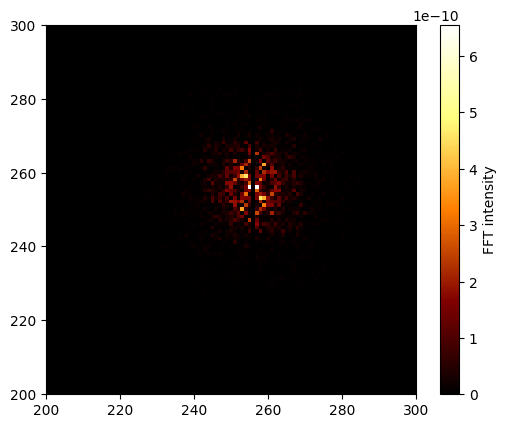

In [21]:
import numpy as np
import matplotlib.pyplot as plt

z = np.load("data_numpy/2nm_QD_AFMs_AIX6461_along_the_flat_edge_1um_200pN_15gain_2um_zrange.0_00000/channel_00___0_data.npy")
z_nobackground = z - np.mean(z)
F = np.fft.fftshift(np.fft.fft2(z_nobackground))

power = np.abs(F)**2

plt.imshow(np.log(power + 1), cmap="afmhot")
plt.colorbar(label="FFT intensity")

plt.xlim(200, 300)
plt.ylim(200, 300)

plt.show()

However, the range is very high. So, lets take the magnitude and plot it on the log scale: 

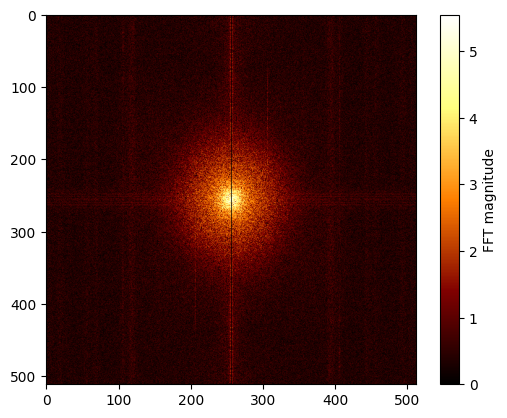

In [22]:
magnitude = np.abs(F)*10e6

plt.imshow(
    np.log1p(magnitude),
    cmap="afmhot"
)

plt.colorbar(label="FFT magnitude")
plt.show()

Using Gaussian filtering, remove the low-frequency background

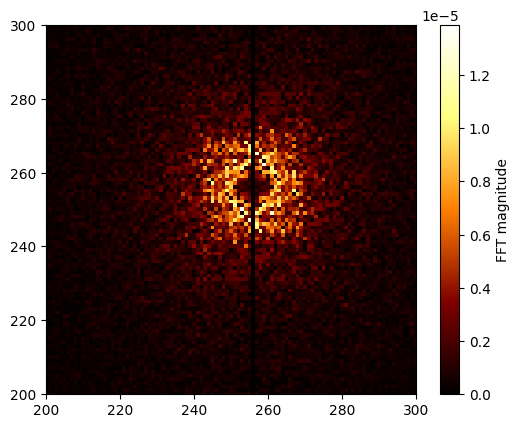

In [23]:
from scipy.ndimage import gaussian_filter

background = gaussian_filter(z, sigma=20)

z_filtered = z - background

F = np.fft.fftshift(np.fft.fft2(z_filtered))

plt.imshow(
    np.log1p(np.abs(F)),
    cmap="afmhot"
)

plt.colorbar(label="FFT magnitude")

plt.xlim(200, 300)
plt.ylim(200, 300)

plt.show()

FFT band-pass filter function testing

In [26]:
from __future__ import annotations

import numpy as np
from scipy.ndimage import gaussian_filter


def fft_bandpass(
    image: np.ndarray,
    low_sigma: float = 1,
    high_sigma: float = 10,
) -> np.ndarray:
    """
    Band-pass filter an AFM image using Fourier space.

    Keeps intermediate spatial frequencies:
    - removes slow background variations
    - removes high-frequency noise

    Parameters
    ----------
    image:
        2D AFM height array

    low_sigma:
        Controls removal of high-frequency noise.
        Smaller = keep finer details.

    high_sigma:
        Controls removal of background.
        Larger = remove larger structures.

    Returns
    -------
    filtered_image:
        Band-pass filtered AFM image
    """

    image = np.asarray(image, dtype=float)

    # remove mean height
    image = image - np.mean(image)

    # FFT
    F = np.fft.fftshift(np.fft.fft2(image))

    ny, nx = image.shape

    y, x = np.indices(image.shape)

    cx = nx // 2
    cy = ny // 2

    r = np.sqrt(
        (x - cx)**2 +
        (y - cy)**2
    )

    # Fourier Gaussian masks
    low_pass = np.exp(
        -(r**2)/(2*high_sigma**2)
    )

    high_pass = 1 - np.exp(
        -(r**2)/(2*low_sigma**2)
    )

    bandpass_mask = low_pass * high_pass

    # apply filter
    F_filtered = F * bandpass_mask

    # inverse FFT
    filtered = np.real(
        np.fft.ifft2(
            np.fft.ifftshift(F_filtered)
        )
    )

    return filtered

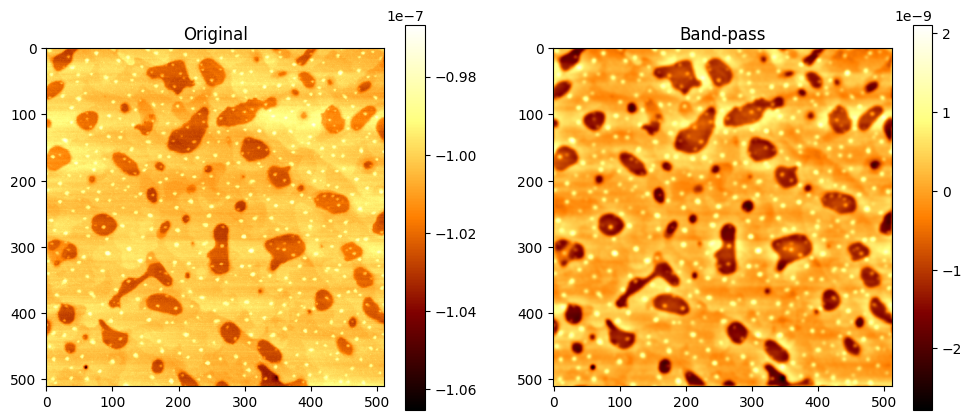

In [27]:
z_filtered = fft_bandpass(
    z,
    low_sigma=5,
    high_sigma=40
)


plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(z, cmap="afmhot")
plt.title("Original")
plt.colorbar()


plt.subplot(1,2,2)
plt.imshow(z_filtered, cmap="afmhot")
plt.title("Band-pass")
plt.colorbar()


plt.show()

Quantum dots appear as halo effect on the FFT, so we can quantify them using FFT or at least try finding their characteristics

The distance from the center corresponds to the inverse of your spatial distances 1/lambda. The angle of the spots indicates the alignment direction of the dots (e.g., self-assembled linear chains along specific crystallographic step edges) 
https://www.sciencedirect.com/science/article/pii/S0169433223001940?__cf_chl_f_tk=YJBFMlXXGtf3M5XObAKVd4wQ49Iv38h0nNXggozaJw0-1783435783-1.0.1.1-FPUAAJPymiutSDDc3XulPfOcpp64fsEhst8XZy4TOx8 

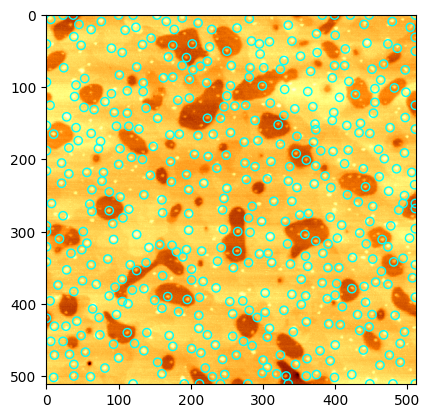

In [41]:
from skimage.feature import blob_log
from sklearn.preprocessing import StandardScaler

z_norm = (
    z_filtered - np.mean(z_filtered)
) / np.std(z_filtered)

blobs = blob_log(
    z_norm,
    min_sigma=2,
    max_sigma=10,
    num_sigma=20,
    threshold=0.5
)

plt.imshow(z, cmap="afmhot")

plt.scatter(
    blobs[:,1],
    blobs[:,0],
    facecolors="none",
    edgecolors="cyan"
)

plt.show()

In [40]:
print(len(blobs))

369
